**Task 4: Loan Approval Prediction Description**

In [1]:
#libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE


In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("loan_approval_dataset.csv")
df.head()


Saving loan_approval_dataset.csv to loan_approval_dataset.csv


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
df.info()
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [9]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


In [10]:
# Fill numeric missing values
num_cols = [
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


# Fill categorical missing values
cat_cols = ['education', 'self_employed']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

le = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

df["loan_status"].value_counts(normalize=True)


/tmp/ipython-input-4287203419.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-4287203419.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,proportion
loan_status,
0,0.62216
1,0.37784


Expected:

Approved ≈ 65–70%
Rejected ≈ 30–35%

In [11]:
y = df['loan_status']
X = df.drop(['loan_status', 'loan_id'], axis=1)


Train- Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



###**Train logistic regression**

In [13]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)



LogisticRegression(max_iter=1000)

In [14]:
y_pred_log = log_model.predict(X_test)



In [15]:
#Result Check
print(classification_report(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))




              precision    recall  f1-score   support

           0       0.80      0.92      0.86       531
           1       0.82      0.63      0.71       323

    accuracy                           0.81       854
   macro avg       0.81      0.77      0.78       854
weighted avg       0.81      0.81      0.80       854

Precision: 0.8244897959183674
Recall: 0.6253869969040248
F1 Score: 0.7112676056338029


####Confusion Matrix

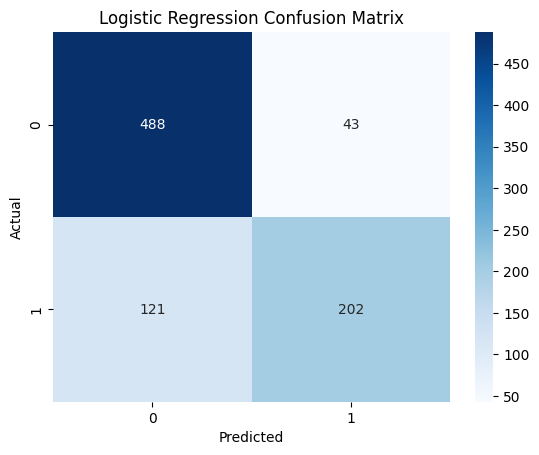

In [16]:
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()



Feature Importance

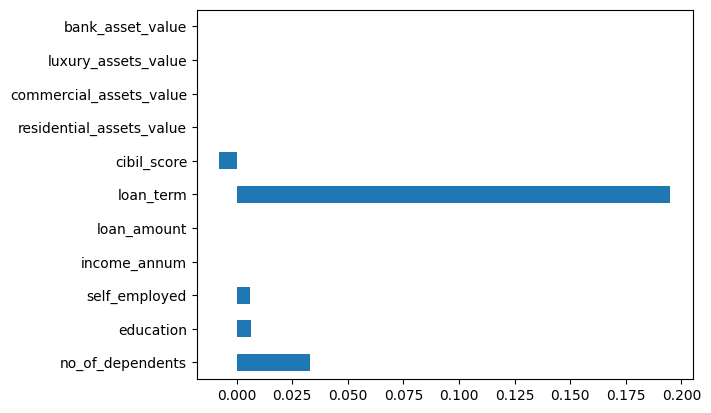

In [26]:
# importances = model.feature_importances_
# feature_names = X.columns

# feat_imp = pd.Series(importances, index=feature_names)
# feat_imp.nlargest(10).plot(kind="barh")
# plt.title("Top 10 Feature Importances (Random Forest)")
# plt.show()
importance = log_model.coef_[0]

feat_imp = pd.Series(importance, index=X.columns)

feat_imp.plot(kind="barh")

plt.show()


####Model 2 XGBoost

In [28]:

from xgboost import XGBClassifier
xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=7,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


In [30]:
from sklearn.metrics import accuracy_score, classification_report

In [31]:
#Cehck Result
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


Accuracy: 0.9812646370023419
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.98      0.97      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



Bonus Part

In [32]:
#apply smote
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


In [33]:
# retrain model
log_smote = LogisticRegression(max_iter=1000)
log_smote.fit(X_train_sm, y_train_sm)

y_pred_sm = log_smote.predict(X_test)

print(classification_report(y_test, y_pred_sm))


              precision    recall  f1-score   support

           0       0.83      0.84      0.84       531
           1       0.73      0.72      0.72       323

    accuracy                           0.79       854
   macro avg       0.78      0.78      0.78       854
weighted avg       0.79      0.79      0.79       854



In [34]:
#train decision tree
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train_sm, y_train_sm)
y_pred_dt = dt.predict(X_test)


In [35]:
#check result
print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       1.00      0.97      0.98       531
           1       0.95      0.99      0.97       323

    accuracy                           0.98       854
   macro avg       0.97      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

